In [1]:
import itertools
import copy

import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib
import argparse

import time

%matplotlib inline

In [2]:
def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    function taken from
    https://stackoverflow.com/questions/7404116/...
        ...defining-the-midpoint-of-a-colormap-in-matplotlib
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower ofset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax/(vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highets point in the colormap's range.
          Defaults to 1.0 (no upper ofset). Should be between
          `midpoint` and 1.0.
    '''
    cdict = {  'red': [],  'green': [], 'blue': [],  'alpha': []  }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    plt.register_cmap(cmap=newcmap)

    return newcmap

In [3]:
def value_iteration(prior_mean, prior_std, bins, raw_bins, args):  
    converge = 0
    
    c1 = args['c1']
    c2 = args['c2']
    c3 = args['c3']

    gamma = args['gamma']
    sigma0 = args['sigma0']
    Sigma1 = args['Sigma1']
    l_0 = args['l_0']
    
    S_square = args['S']**2
    value = np.zeros((args['K'], S_square))
    pi = np.zeros((args['K'], S_square))
    
    # Generate middle of the bins as representation of state
    new_bins_2d = []
    raw_new_bins = []
    flag = []
    
    for k in range(args['K']):
        raw_bins_k = raw_bins[k]
        
        new_bins_state_1 = copy.deepcopy(raw_bins_k[0])
        new_bins_state_2 = copy.deepcopy(raw_bins_k[1])

        state_1_space = np.diff(raw_bins_k[0])[0] 
        state_2_space = np.diff(raw_bins_k[1])[0]

        new_bins_state_1[1:] = raw_bins_k[0][1:] - state_1_space/ 2
        new_bins_state_1 = np.append(new_bins_state_1, args['s1_limit'])

        new_bins_state_2[1:] = raw_bins_k[1][1:] - state_2_space / 2
        new_bins_state_2 = np.append(new_bins_state_2, args['s1_limit'] * (k+1))
        
        new_bins_2d_k = np.stack(list(itertools.product(new_bins_state_1, new_bins_state_2)))
        raw_new_bins_k = (new_bins_state_1, new_bins_state_2)
        
        # Append middle of the bins
        new_bins_2d.append(new_bins_2d_k)
        raw_new_bins.append(raw_new_bins_k)
        
        # Flag some spaces to white
        flag_k = new_bins_2d_k[:, 1] <= new_bins_2d_k[:, 0] * (k+1)
        flag.append(flag_k)
        
    # Pre calculate transition probability to avoid repetition when doing value iteration 
    prob = calc_transition_prob(new_bins_2d, raw_new_bins, bins, prior_mean, prior_std, args)
    
    # Time how long the VI runs
    start = time.time()
    for i in range(args['max_iter']):
        old_value = copy.deepcopy(value)
#         print(value[0, :].reshape(args['S'], args['S']))
        for k in range(args['K']-1):
            for s in range(S_square):
                # At state (k, s)
                # Check edge case
                lk = new_bins_2d[k][s, 0]
                if lk > args['r_limit']:
                    value[k, s] = c1 + gamma * value[0, 0]
                    pi[k, s] = 1
                    continue

                if k == args['K'] - 1:
                    value[k, s] = c3 if lk <= args['r_limit'] else c1
                    pi[k, s] = 0 if lk <= args['r_limit'] else 1
                    continue

                # Two possible actions: replace and not replace
                # Calculate transition probability
                curr_prob = prob[k, s]
                future_cost = gamma * value[k+1, :]

                # Evaluate value of current state
                cost_A0 = np.sum(np.multiply(curr_prob, c3 + future_cost)) # Not replacing machine
                cost_A1 = c2 + gamma * value[0, 0] # Replacing machine
                
#                 print(f"k = {k} | state {new_bins_2d[s]} | A0 = {cost_A0} | A1 = {cost_A1}")
                
                value[k, s] = max(cost_A0, cost_A1)
                pi[k, s] = int(cost_A0 < cost_A1)
            
#         if i % 5 == 0:
#         print(f"Iter {i+1}: gap = {np.linalg.norm(old_value - value)}")
        if np.linalg.norm(old_value - value) < args['threshold']:
            converge = 1
            break 
    if converge == 0:
        print("Reach maximum iteration before convergent")
        
    end = time.time()
    elapsed = end - start
    print(f"Complete value iteration. Elapsed time = {elapsed // 60} mins {elapsed % 60} seconds")

    return value, pi, prob, flag

In [4]:
def calc_one_step_transition_prob(s_k_index, mean, std, s_k, v_array, h_array, new_bins, s2_limit, args):
    # Declare variable
#     print(f"At state {s_k_index} ({s_k})")
#     print(f"mean = {mean} | std = {std}")

    v_counter = s_k_index[0]; h_counter = s_k_index[1];
    ss_1, ss_2 = new_bins
    prob = np.zeros((args['S'], args['S']))
    curr_ss1 = s_k[0]; curr_ss2 = s_k[1]
    intersection_list = [s_k]
    
    while np.abs(curr_ss1 - args['s1_limit']) > args['epsilon'] and np.abs(curr_ss2 - s2_limit) > args['epsilon']:
        next_v_xaxis = v_array[v_counter+1, 0]
        next_h_xaxis = h_array[h_counter+1, 0]
        if np.abs(next_h_xaxis - next_v_xaxis) <= args['epsilon']:
            end_point = v_array[v_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter + 1
            new_h_counter = h_counter + 1
            
        elif next_v_xaxis > next_h_xaxis:
            end_point = h_array[h_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter
            new_h_counter = h_counter + 1
            
        elif next_v_xaxis < next_h_xaxis:
            end_point = v_array[v_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter + 1
            new_h_counter = h_counter

        # Update posterior for current state at (v_counter, h_counter)
        # Transform end_point and starting_point into x_1 and x_2
        x_1 = (starting_point[0] - s_k[0]) / args['delta']
        x_2 = (end_point[0] - s_k[0]) / args['delta']
        
        # Normalize x_1 and x_2
        z_1 = (x_1 - mean) / std
        z_2 = (x_2 - mean) / std
        
        # Find standard normal CDF of x_1 and x_2
        F_1 = scipy.stats.norm.cdf(z_1)
        F_2 = scipy.stats.norm.cdf(z_2)

        transition_prob = F_2 if (starting_point == s_k).all() else F_2 - F_1
        prob[v_counter, h_counter] = transition_prob
#         print(f"transition to state {(v_counter, h_counter)} | transition prob. = {transition_prob}")
        
        # Update the list of interesecting points
        intersection_list.append(end_point)
        curr_ss1 = end_point[0]; curr_ss2 = end_point[1]
        
        # Update v_counter and h_counter
        v_counter_old = v_counter; v_counter = new_v_counter;
        h_counter_old = h_counter; h_counter = new_h_counter;

    intersection_list = np.stack(intersection_list)
    prob[v_counter, h_counter] = 1 - np.sum(prob)
#     print(f"transition to state {(v_counter, h_counter)} | transition prob. = {prob[v_counter, h_counter]}")
#     print('-------------------------')
    
    # Reshape prob
    prob = prob.flatten()
    
    return prob

def calc_transition_prob(state_partition, new_bins, bins, prior_mean, prior_cov, args):
    # Declare variables
    sigma0 = args['sigma0']
    extended_state_space = args['S'] ** 2
    
    # Inverse covaraince
    inv_prior_cov = np.linalg.inv(prior_cov)

    # Matrix of K x S x S
    prob = np.zeros((args['K'], extended_state_space, extended_state_space))
    for k in range(args['K']-1):
#         print(f"----------k = {k}-------------")
        ss_1, ss_2 = new_bins[k]
    
        delta_poly = (args['delta'] ** np.arange(1, 3)).reshape(-1, 1)
        tk_plus1 =  np.multiply(delta_poly, np.array([[1], [k+1]]))
    
        # Compute A_k in advance
        tk_list = np.vstack((np.repeat(1, k), np.arange(1, k+1)))
        T_list = np.multiply(delta_poly, tk_list)
        
        A_k = np.linalg.inv((1/sigma0**2) * (T_list @ T_list.T) + inv_prior_cov)
        t_A_k = tk_plus1.T @ A_k
        t_A_t_k = (t_A_k @ tk_plus1).item()
        
        # Compute sigma_k
        sigma_k = np.sqrt(sigma0**2 + t_A_t_k)
        
        for s in range(extended_state_space):
            # Retrieve state index
            state_index = (s // args['S'], s % args['S'])
            s_k = state_partition[k][s]
            
            # Calculate the state limit
            upper_limit_slope = args['delta'] * (k + 1.5)
            lower_limit_slope = args['delta'] / 2
            state_cond_upper = upper_limit_slope * s_k[0]
            state_cond_lower = lower_limit_slope * s_k[0]
            
            # Calculate t_k and t_{k+1}
                
            if s_k[1] <= state_cond_upper and s_k[1] >= state_cond_lower:
                if k > 0:                
                    # Calculate A_k and b_k which are components in our posterior
                    b_k = (1/sigma0**2) * s_k.reshape(-1, 1) + inv_prior_cov @ prior_mean

                else:
                    A_k = prior_cov
                    b_k = np.linalg.solve(prior_cov, prior_mean)

                # Posterior mean 
                mu_k = (t_A_k @ b_k).item()

                # p2 is the mean of predictive distribution
                p2 = (s_k[0] + mu_k * tk_plus1[0, 0], s_k[1] + mu_k * tk_plus1[1, 0])

                # Calculate slope
                m = tk_plus1[1, 0] / tk_plus1[0, 0]
                b = p2[1] - m * p2[0]

                # Calculate the intersection with the grid
                v_intersection = m * ss_1 + b
                h_intersection = (1/m) * (ss_2 - b)
                v_array = np.vstack((ss_1, v_intersection)).T
                h_array = np.vstack((h_intersection, ss_2)).T

                # Calculate transition prob.
                s2_limit = args['s1_limit'] * (k+1)
                prob[k, s, :] = calc_one_step_transition_prob(state_index, mu_k, sigma_k, s_k, v_array, h_array, new_bins[k], s2_limit, args)
    return prob

def calc_cost(k, args, cost_type):
    replace_cost = args['c1'] if cost_type == 'urgent' else args['c2']
    if args["gamma"] == 1:
        cost = k * args["c3"] + replace_cost
    else:
        cost = args["c3"]*(1-args["gamma"]**(k+1))/(1-args["gamma"]) + replace_cost*args["gamma"]**k    
    return cost

def get_prior(args):
    N = args['N']
    Sigma1 = args['Sigma1']
    Sigma2 = args['Sigma2']
    Sigma3 = args['Sigma3']
    
    inv_Sigma1 = np.linalg.inv(Sigma1)
    inv_Sigma2 = np.linalg.inv(Sigma2)
    inv_Sigma3 = np.linalg.inv(Sigma3)
    
    # Compute precision matrix and linear shift term
    A = np.block([[np.kron(np.eye(N), inv_Sigma1)  , -np.kron(np.eye(N), inv_Sigma1), np.zeros((2*N, 2))],
                  [-np.kron(np.eye(N), inv_Sigma1) ,  np.kron(np.eye(N), inv_Sigma1 + inv_Sigma2), -np.kron(np.ones((N, 1)), inv_Sigma2)],
                  [np.zeros((2, 2*N)), -np.kron(np.ones((1, N)), inv_Sigma2), N*inv_Sigma2 + inv_Sigma3]])
    b = np.block([[np.zeros((2*N, 1))],
                  [np.zeros((2*N, 1))],
                  [inv_Sigma3 @ args['mu3']]])
    
    # Prior of all terms
    theta_mean = np.linalg.solve(A, b)
    theta_cov = np.linalg.inv(A)
    return theta_mean, theta_cov

def update_collaborative_posterior(lk_list, m_list, args):
    # Variables
    d = args['d']
    N = args['N']
    total_m = np.sum(m_list)
    
    I_N = np.eye(N)
    
    Sigma1 = args['Sigma1']; Sigma2 = args['Sigma2']; Sigma3 = args['Sigma3']
    inv_Sigma1 = np.linalg.inv(args['Sigma1']); inv_Sigma2 = np.linalg.inv(args['Sigma2']); inv_Sigma3 = np.linalg.inv(args['Sigma3'])
    
    # Create a block matrix on top-left
    beta_block_A = np.kron(np.eye(total_m), inv_Sigma1) 
    beta_block_B = np.zeros((total_m*d, 1))
    
    beta_mu1_block_A = np.kron(np.repeat(I_N, repeats=m_list, axis=0), -inv_Sigma1)
    beta_mu2_block_A = np.zeros((total_m*d, d))
    
    mu1_block_A = np.zeros((N*d, N*d))
    mu1_block_B = np.zeros((N*d, 1))
    
    mu1_mu2_block_A = np.kron(np.ones((N, 1)), -inv_Sigma2)
    mu2_block_A = N * inv_Sigma2 + inv_Sigma3
    mu2_block_B = inv_Sigma3 @ args['mu3']
    
    sum_m = 0
    for i in range(args['N']):
        lk_i_list = lk_list[i]
        mu1_block_A[i*d:(i+1)*d, i*d:(i+1)*d] = m_list[i] * inv_Sigma1 + inv_Sigma2
        
        # Set up beta_mu1_block
        for m in range(m_list[i]):
#             print(f'Site {i} | lk = {lk_i_list[m]}')
            for k, diff_lk in lk_i_list[m]:
                tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(d)).reshape(-1, 1)
                tt_k_matrix = tt_k @ tt_k.T
                diff_lk_tk = diff_lk * tt_k
                
                # Update sub-matrix in A (second-order term)
                beta_block_A[sum_m+m*d: sum_m+(m+1)*d, sum_m+m*d: sum_m+(m+1)*d] += (1/args['sigma0']**2) * tt_k_matrix 
                
                # Update sub-matrix in b (first-order term)
                beta_block_B[sum_m+m*d: sum_m+(m+1)*d] += (1/args['sigma0']**2) * diff_lk_tk
                
            sum_m += m_list[i]*d

    # Concatenate everything
    A = np.block([[beta_block_A, beta_mu1_block_A, beta_mu2_block_A],
                  [beta_mu1_block_A.T, mu1_block_A, mu1_mu2_block_A],
                  [beta_mu2_block_A.T, mu1_mu2_block_A.T, mu2_block_A]])
    B = np.block([[beta_block_B],
                  [mu1_block_B],
                  [mu2_block_B]])

    # Solve for posterior
    theta_posterior_mean = np.linalg.solve(A, B)
    theta_posterior_cov = np.linalg.inv(A)
    
    # Put posterior in list
    sum_m = 0
    beta_mean = [[] for n in range(N)]
    beta_cov = [[] for n in range(N)]
    for i in range(N):
        for m in range(m_list[i]):
            beta_mean[i].append(theta_posterior_mean[sum_m+m*d: sum_m+(m+1)*d])
            beta_cov[i].append(theta_posterior_cov[sum_m+m*d: sum_m+(m+1)*d, sum_m+m*d: sum_m+(m+1)*d])
        sum_m += m_list[i]*d
    
    
    return beta_mean, beta_cov

In [5]:
def sample_transition(beta, args):
    lk_list = np.zeros(args['K'])
    lk_list[0] = args['l_0']
    for t in range(1, args['K']):
        beta_term = 0
        for degree in range(args['d']):
            beta_term += beta[degree] * ((t)**(degree)) * (args['delta']**(degree+1))
        lk_list[t] = lk_list[t-1] + beta_term + np.random.randn(1)[0] * args['sigma0']
    
    return lk_list

def discretize_states(lk_list, bins):
    discrete_state_space = np.digitize(lk_list, bins, right=False)
    return discrete_state_space

def simulation(args, experiment='collaborative'):
    hist_lk_tensor = np.zeros((args['N'], args['M'], args['K']))
    hist_diff_lk_tensor = np.zeros((args['N'], args['M'], args['K']))
    hist_cost_tensor = np.zeros((args['N'], args['M'], args['K']))
    state_2 = np.zeros((args['N'], args['M'], args['K']))

    discrete_state_1 = np.zeros((args['N'], args['M'], args['K']))
    discrete_state_2 = np.zeros((args['N'], args['M'], args['K']))

    # Create bins to discretize states
    bins_state_1 = np.linspace(args['l_0'], args['s1_limit'], args['S']-1)
    bins_state_2 = []
    bins_2d = []
    raw_bins = []
    
    for k in range(args['K']):
        bins_state_2_k = np.linspace(args['l_0'], args['s1_limit'] * (k+1), args['S']-1)
        bins_state_2.append(bins_state_2_k)
        
        # Cross-product of all bins
        bins_2d_k = np.stack(list(itertools.product(bins_state_1, bins_state_2_k)))
        bins_2d.append(bins_2d_k)
        raw_bins.append((bins_state_1, bins_state_2_k))
    
    mu1_true = np.random.multivariate_normal(mean=args['mu_true'].flatten(), cov=args['Sigma2'], size=args['N'])
    true_beta = np.zeros((args['N'], args['M'], args['d']))
    # Generate true parameters for N sites and M machines
    for n in range(args['N']):
        beta_n = np.random.multivariate_normal(mean=mu1_true[n], cov=args['Sigma1'], size=args['M'])
        true_beta[n, :, :] = beta_n
        for m in range(args['M']):
            hist_lk_tensor[n, m, :] = sample_transition(beta_n[m, :], args)
            hist_diff_lk_tensor[n, m, 1:] = np.diff(hist_lk_tensor[n, m, :])
            hist_diff_lk_tensor[n, m, 0] = hist_lk_tensor[n, m, 0]
    
            # Extract states
            state_1 = np.multiply(args['delta'], hist_lk_tensor)
            
            # Discretize states
            discrete_state_1[n, m, :] = discretize_states(state_1[n, m, :], bins_state_1)
            
            # States in 2nd dimension
            state_2[n, m, 0] = hist_diff_lk_tensor[n, m, 0]
            for k in range(1, args['K']):
                state_2[n, m, k] = state_2[n, m, k-1] +  hist_diff_lk_tensor[n, m, k] * k * args['delta']**2
                discrete_state_2[n, m, k] = discretize_states(state_2[n, m, k], bins_state_2[k])
    
    discrete_state_1 = discrete_state_1.astype(int)
    discrete_state_2 = discrete_state_2.astype(int)
    
    # Running posterior update
    m_counter = np.ones(args['N']).astype(int)
    k_counter = np.ones(args['N']).astype(int)
    
    theta_mean, theta_cov = get_prior(args)
    beta_mean = theta_mean[:2*args['N']]
    beta_cov = theta_cov[:2*args['N']]
    
    hist_cost_list = [[] for n in range(args['N'])]
    hist_lk_list = [[[] for n in range(args['M'])] for n in range(args['N'])]
    
    for t in range(args['max_T']):
        print(f"----- Time = {t} -----")
        # Check termination condition
        if np.all(m_counter == args['M']):
            break
        for i in range(args['N']):  
            # Check update skip condition
            if m_counter[i] == args['M']:
                continue
                
            # Variables
            m = m_counter[i]
            m_idx = m - 1
            k = k_counter[i]
            
            # States
            c_state_1 = state_1[i, m_idx, k]
            c_state_2 = state_2[i, m_idx, k]
            
            # Discrete states
            d_state_1 = discrete_state_1[i, m_idx, k]
            d_state_2 = discrete_state_2[i, m_idx, k]
            
            # Diff lk
            diff_lk = hist_diff_lk_tensor[i, m_idx, k]
            
            # Retrieve prior for site i for t = 0
            if t == 0:
                beta_i_mean = beta_mean[2*i:2*(i+1)]
                beta_i_cov = beta_cov[2*i:2*(i+1), 2*i:2*(i+1)]
            else:
                beta_i_mean = beta_mean[i][-1]
                beta_i_cov = beta_cov[i][-1]
            
            print(f"site {i} | true beta = {true_beta[i, m_idx, :].flatten()} beta mean = {beta_i_mean.flatten()} | beta std = {np.diag(beta_i_cov)}")
            
            # Save history
            hist_lk_list[i][m_idx].append((k, diff_lk))
            
#             Running only VI from prior
#             if experiment == 'collaborative':
#                 value, pi, prob, flag = value_iteration(beta_i_mean, beta_i_cov, bins_2d, raw_bins, args)
            
#             # Determine the action from pi (policy) and replacement limit
#             if c_state_1 > args['r_limit'] or pi[d_state_1, d_state_2] > 0.5:
#                 cost_type = 'urgent' if c_state_1 > args['r_limit'] else 'schedule'
#                 cost = calc_cost(k, args, cost_type)
                
#                 print(f"Site {i} | machine #{m} | cost={cost}")
                
#                 # Append the cost
#                 hist_cost_list[i].append(cost)
                
#                 # Increment the counters
#                 m_counter[i] += 1
#                 k_counter[i] = 0
            
        ### *Update posterior ###
#         beta_mean, beta_cov = update_collaborative_posterior(hist_lk_list, m_counter, args)
        beta_mean, beta_cov = update_posterior(hist_lk_list, args)

        # Increment k at the end of every sweep
        k_counter += 1 
    return hist_lk_list, hist_cost_list

In [6]:
def update_posterior(diff_lk_list, args):
    '''
    diff_lk_list (list) - list of transition at timestep k minus transition at timestep k-1
    args (dict) - dict containing parameters
    t (int) - timestep at which the posterior is updated.
    '''
    d = args['d']
    N = args['N']
    
    ##### Initialize A #####
    # Inverse of Sigma1, Sigma2, and Sigma 3 are going to be used a lot
    if args['Sigma1'].ndim == 1:
        Sigma1_inv, Sigma2_inv, Sigma3_inv = 1/args['Sigma1'], 1/args['Sigma2'], 1/args['Sigma3']
    else:
        Sigma1_inv, Sigma2_inv, Sigma3_inv = np.linalg.inv(args['Sigma1']), np.linalg.inv(args['Sigma2']), np.linalg.inv(args['Sigma3'])
    
    ##### Initialize B #####
    # Big vector
    B = np.zeros(((2*N+1)*d, 1))
    beta_B = np.zeros((N*d, 1))
    
    # Big matrix
    A = np.zeros(((2*N+1)*d, (2*N+1)*d))
    
    # Construct A_t by constructing a sub-matrix
    # Construct sub-matrix pertaining to beta^{(i, j)}
    
    beta_matrix = np.zeros((N * d, N * d ))
    
    # Loop over n to fill in matrix
    for n in range(N):
        beta_matrix[n*d:(n+1)*d, n*d:(n+1)*d] += Sigma1_inv
        diff_lk_i = diff_lk_list[n][0]
        for k, diff_lk in diff_lk_i:
#             tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(1, d+1) - (k-1) ** np.arange(1, d+1)).reshape(-1, 1)
            tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(d)).reshape(-1, 1)
            tt_k_matrix = tt_k @ tt_k.T
            
            # Update sub-matrix in A
            beta_matrix[n*d:(n+1)*d, n*d:(n+1)*d] += (1/args['sigma0']**2) * tt_k_matrix
            
            # Update sub-matrix in B
            diffl_tk = diff_lk * tt_k
            beta_B[n*d:(n+1)*d] += (1/args['sigma0']**2) * diffl_tk

    A[:N*d, :N*d] = beta_matrix
    B[:N*d, 0] = beta_B.flatten()

    # Construct mu1 sub-matrix
    mu1 = np.zeros((N*d, N*d))
    
    # Assign values to mu1^{(i)}
    for n in range(N):
        mu1[n*d:(n+1)*d, n*d:(n+1)*d] = Sigma1_inv
        
    # Assign value to off-diagonal square matrices of mu1^{(i)} and beta^{(i, j)}
    A[:N*d, N*d:2*(N*d)] = -mu1
    A[N*d:2*(N*d), :N*d] = -mu1

    # Add Sigma2
    for n in range(N):
        mu1[n*d:(n+1)*d, n*d:(n+1)*d] += Sigma2_inv
    A[N*d:2*(N*d), N*d:2*(N*d)] = mu1
    
    # Construct mu2
    mu2 = N * Sigma2_inv + Sigma3_inv
    A[2*(N*d):, 2*(N*d):] = mu2
    
    mu2_mu1_interact = np.zeros((N*d, d)) 
    
    # Assign value to off-diagonal of mu2 and mu1^{i}
    for n in range(N):
        mu2_mu1_interact[n*d:(n+1)*d, :] = -Sigma2_inv
        
    A[N*d : 2*(N*d), 2*(N*d):] = mu2_mu1_interact
    A[2*(N*d):, N*d : 2*(N*d)] = mu2_mu1_interact.T
    
    # Assign value of mu2
    B[2*(N*d):] = Sigma3_inv @ args['mu3']   
    
    # Solve for posterior
    post_mean = np.linalg.solve(A, B)
    post_cov = np.linalg.inv(A)
    
    post_std = np.sqrt(np.diag(post_cov))
    
    sum_m = 0
    beta_mean = [[] for n in range(N)]
    beta_cov = [[] for n in range(N)]
    m_list = np.ones(N).astype(int)
    for i in range(N):
        for m in range(m_list[i]):
            beta_mean[i].append(post_mean[sum_m+m*d: sum_m+(m+1)*d])
            beta_cov[i].append(post_cov[sum_m+m*d: sum_m+(m+1)*d, sum_m+m*d: sum_m+(m+1)*d])
        sum_m += m_list[i]*d
    
    return beta_mean, beta_cov

In [9]:
args = {
    # Hierarchical graph params
    'delta': 1, 'mu3': np.array([[5], [1]]), 'Sigma3': np.array([[5, 0], [0, 5]]), 
    'Sigma2': np.array([[1e-2     , 0], [0, 1e-4]]), 'Sigma1': np.array([[0.1, 0], [0, 0.01]]),
    'sigma0': 1, 'l_0': 0, 'mu_true': np.array([[1], [0.3]]),
    # Simulation params
    'N': 10, 'M': 30, 'K': 2100, 'S': 20, 's1_limit': 41, 'r_limit': 40, 'd': 2, 'max_T': 2000, 
    # Value iteration params
    'c1':  -20, 'c2': -5, 'c3': -0.05, 'max_iter': 5000, 'threshold': 1e-3, 'gamma': 0.99, 'epsilon':1e-6
}
lk_list, cost_list = simulation(args)

----- Time = 0 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 8 | true beta = [0.88581598 0.31026323] beta mean = [5. 1.] | beta std = [5.11   5.0101]
site 9 | true beta = [0.99295106 0.22488704] beta mean = [5. 1.] | beta std = [5.11   5.0101]
----- Time = 1 -----
site 0 | true beta

----- Time = 38 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.26144979 0.33125414] | beta std = [0.05992127 0.00014252]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.91293413 0.23392797] | beta std = [0.05992127 0.00014252]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.6368052  0.23208364] | beta std = [0.05992127 0.00014252]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [0.93323786 0.41345488] | beta std = [0.05992127 0.00014252]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.41491924 0.15116973] | beta std = [0.05992127 0.00014252]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.84558302 0.3245296 ] | beta std = [0.05992127 0.00014252]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.88415808 0.30041055] | beta std = [0.05992127 0.00014252]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.06372801 0.21886197] | beta std = [0.05992127 0.00014252]
site 8 | true beta = [0.88581598 0

site 3 | true beta = [0.79021558 0.40627992] beta mean = [1.00889313 0.40661443] | beta std = [4.57210144e-02 4.49505953e-05]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.42578004 0.15059934] | beta std = [4.57210144e-02 4.49505953e-05]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.81092169 0.32890049] | beta std = [4.57210144e-02 4.49505953e-05]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.80126989 0.30928598] | beta std = [4.57210144e-02 4.49505953e-05]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.05921873 0.21904152] | beta std = [4.57210144e-02 4.49505953e-05]
site 8 | true beta = [0.88581598 0.31026323] beta mean = [0.84224087 0.31205159] | beta std = [4.57210144e-02 4.49505953e-05]
site 9 | true beta = [0.99295106 0.22488704] beta mean = [0.9750869  0.22220283] | beta std = [4.57210144e-02 4.49505953e-05]
----- Time = 59 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.34588743 0.32551297] | beta std = [4

----- Time = 69 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.37010861 0.32426053] | beta std = [4.05138208e-02 2.77732778e-05]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.7556501  0.24934733] | beta std = [4.05138208e-02 2.77732778e-05]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.69247958 0.22707661] | beta std = [4.05138208e-02 2.77732778e-05]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [1.03674929 0.40495898] | beta std = [4.05138208e-02 2.77732778e-05]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.45934024 0.14893882] | beta std = [4.05138208e-02 2.77732778e-05]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.78595053 0.33032896] | beta std = [4.05138208e-02 2.77732778e-05]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.78855468 0.31024873] | beta std = [4.05138208e-02 2.77732778e-05]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.06373872 0.21890368] | beta std = [4

----- Time = 76 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.41982247 0.32169332] | beta std = [3.77876268e-02 2.12088343e-05]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.66985494 0.25348991] | beta std = [3.77876268e-02 2.12088343e-05]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.66275564 0.22852215] | beta std = [3.77876268e-02 2.12088343e-05]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [1.0544972  0.40394725] | beta std = [3.77876268e-02 2.12088343e-05]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.47064111 0.14828076] | beta std = [3.77876268e-02 2.12088343e-05]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.79004151 0.33006579] | beta std = [3.77876268e-02 2.12088343e-05]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.79921598 0.30971391] | beta std = [3.77876268e-02 2.12088343e-05]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.05940804 0.21912264] | beta std = [3

...

----- Time = 489 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.28778902 0.32210407] | beta std = [7.69232438e-03 9.78102845e-08]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.59300089 0.25621423] | beta std = [7.69232438e-03 9.78102845e-08]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.55422386 0.23025365] | beta std = [7.69232438e-03 9.78102845e-08]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [0.96735881 0.4056481 ] | beta std = [7.69232438e-03 9.78102845e-08]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.53412811 0.14708831] | beta std = [7.69232438e-03 9.78102845e-08]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.46598032 0.33756178] | beta std = [7.69232438e-03 9.78102845e-08]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.66565199 0.3119592 ] | beta std = [7.69232438e-03 9.78102845e-08]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.24873777 0.21401108] | beta std = [

----- Time = 498 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.29840228 0.32203641] | beta std = [7.56139283e-03 9.26796768e-08]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.59862399 0.25617756] | beta std = [7.56139283e-03 9.26796768e-08]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.56315789 0.23019659] | beta std = [7.56139283e-03 9.26796768e-08]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [0.95246229 0.40573952] | beta std = [7.56139283e-03 9.26796768e-08]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.52564147 0.14713981] | beta std = [7.56139283e-03 9.26796768e-08]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.4593143  0.33760238] | beta std = [7.56139283e-03 9.26796768e-08]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.62765079 0.31219668] | beta std = [7.56139283e-03 9.26796768e-08]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.24747723 0.21401783] | beta std = [

----- Time = 507 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.29985086 0.32202578] | beta std = [7.43484590e-03 8.79018041e-08]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.57519743 0.25631985] | beta std = [7.43484590e-03 8.79018041e-08]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.56118315 0.23020632] | beta std = [7.43484590e-03 8.79018041e-08]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [0.94227973 0.40580071] | beta std = [7.43484590e-03 8.79018041e-08]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.52702088 0.14712875] | beta std = [7.43484590e-03 8.79018041e-08]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.44323064 0.33769941] | beta std = [7.43484590e-03 8.79018041e-08]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.6046619  0.31233667] | beta std = [7.43484590e-03 8.79018041e-08]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.22593744 0.21414795] | beta std = [

----- Time = 516 -----
site 0 | true beta = [1.25020757 0.32213433] beta mean = [1.28164567 0.32213552] | beta std = [7.31246686e-03 8.34468596e-08]
site 1 | true beta = [0.58338218 0.25626774] beta mean = [0.59064013 0.25622629] | beta std = [7.31246686e-03 8.34468596e-08]
site 2 | true beta = [0.67214127 0.22966683] beta mean = [0.5397451  0.23033591] | beta std = [7.31246686e-03 8.34468596e-08]
site 3 | true beta = [0.79021558 0.40627992] beta mean = [0.92740994 0.40589076] | beta std = [7.31246686e-03 8.34468596e-08]
site 4 | true beta = [1.46634457 0.14709793] beta mean = [1.53363593 0.14708851] | beta std = [7.31246686e-03 8.34468596e-08]
site 5 | true beta = [0.51110641 0.33746902] beta mean = [0.47081236 0.33753279] | beta std = [7.31246686e-03 8.34468596e-08]
site 6 | true beta = [0.40173802 0.31324046] beta mean = [0.613131   0.31228537] | beta std = [7.31246686e-03 8.34468596e-08]
site 7 | true beta = [1.16324863 0.21438253] beta mean = [1.23635006 0.21408445] | beta std = [


KeyboardInterrupt



In [ ]:
orig_cmap = matplotlib.cm.binary
shifted_cmap = shiftedColorMap(orig_cmap, midpoint=0.005, name='shifted_cm_bin_01')

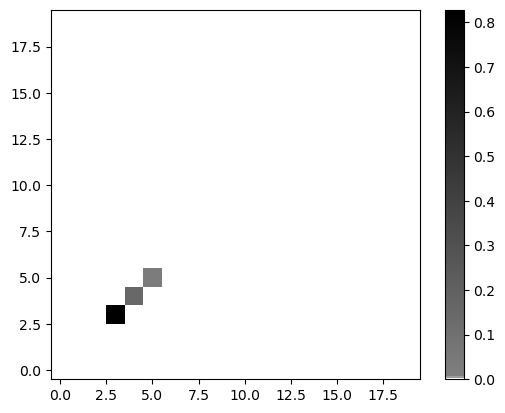

In [206]:
prob_plot = prob[50][63, :].reshape(20, 20, order='F')
plt.imshow(prob_plot, cmap=plt.get_cmap('shifted_cm_bin_01'), origin='lower')
# plt.imshow(prob_plot, cmap=plt.get_cmap('shifted_cm_bin01'),  norm=matplotlib.colors.LogNorm(vmin=1e-8, vmax=prob_plot.max()), origin='lower')
plt.colorbar()
plt.show()

# Plot

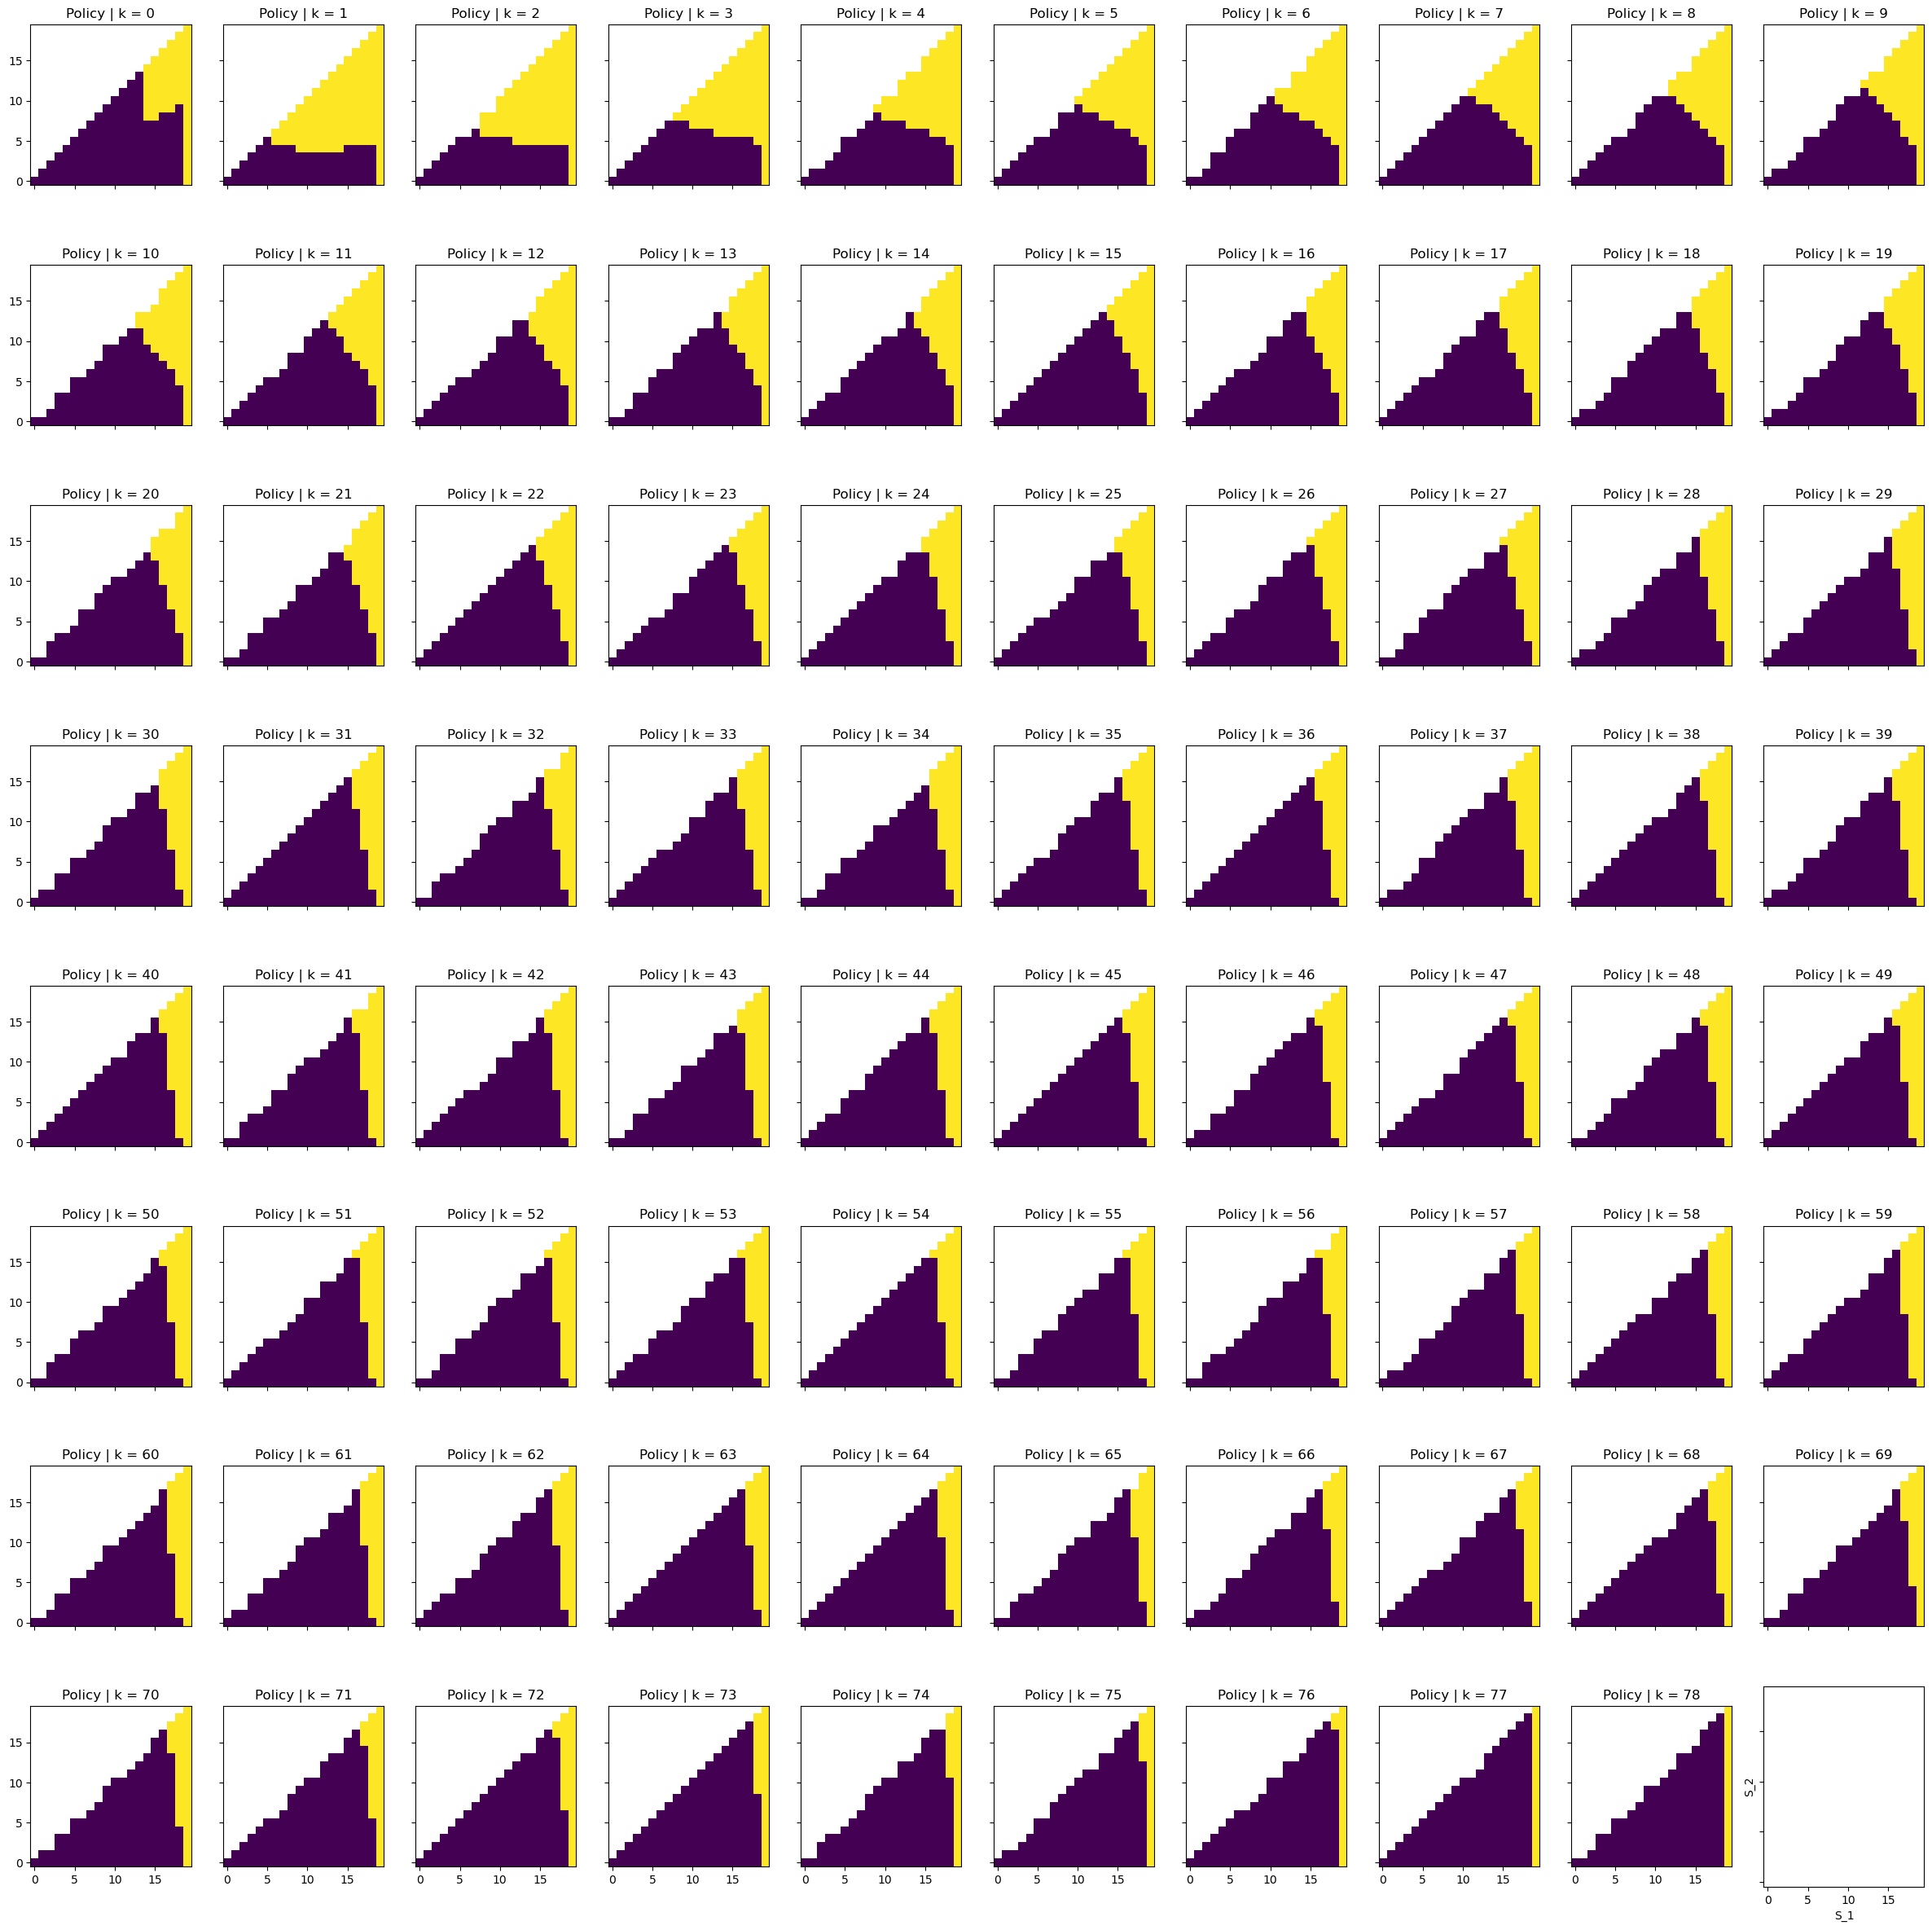

In [230]:
S = 20
K = 80
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag[k].reshape(S, S)
    pi_2d = pi[k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')

fig.savefig('policy.svg')

## Note
- $t_{k+1}^\top A_k$ can be calculated only once and does not depend on $S_k$

# Recycle bin

In [ ]:
def calc_one_step_transition_prob(s_k_index, mean, std, s_k, v_array, h_array, new_bins, args):
    # Declare variable
    print(f"At state {s_k_index} ({s_k})")
    print(f"mean = {mean} | std = {std}")

    v_counter = s_k_index[0]; h_counter = s_k_index[1];
    ss_1, ss_2 = new_bins
    prob = np.zeros((args['S'], args['S']))
    curr_ss1 = s_k[0]; curr_ss2 = s_k[1]
    intersection_list = [s_k]

    while curr_ss1 < args['s1_limit'] and curr_ss2 < args['s2_limit']:
        next_v_xaxis = v_array[v_counter+1, 0]
        next_h_xaxis = h_array[h_counter+1, 0]
        if np.abs(next_h_xaxis - next_v_xaxis) <= args['epsilon']:
            end_point = v_array[v_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter + 1
            new_h_counter = h_counter + 1
            
        elif next_v_xaxis > next_h_xaxis:
            end_point = h_array[h_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter
            new_h_counter = h_counter + 1
            
        elif next_v_xaxis < next_h_xaxis:
            end_point = v_array[v_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter + 1
            new_h_counter = h_counter

        # Update posterior for current state at (v_counter, h_counter)
        # Transform end_point and starting_point into x_1 and x_2
        x_1 = (starting_point[0] - s_k[0]) / args['delta']
        x_2 = (end_point[0] - s_k[0]) / args['delta']
        
        # Normalize x_1 and x_2
        z_1 = (x_1 - mean) / std
        z_2 = (x_2 - mean) / std
        
        # Find standard normal CDF of x_1 and x_2
        F_1 = scipy.stats.norm.cdf(z_1)
        F_2 = scipy.stats.norm.cdf(z_2)

        transition_prob = F_2 if (starting_point == s_k).all() else F_2 - F_1
        prob[v_counter, h_counter] = transition_prob
        print(f"transition to state {(v_counter, h_counter)} | transition prob. = {transition_prob}")
        
        # Update the list of interesecting points
        intersection_list.append(end_point)
        curr_ss1 = end_point[0]; curr_ss2 = end_point[1]
        
        # Update v_counter and h_counter
        v_counter_old = v_counter; v_counter = new_v_counter;
        h_counter_old = h_counter; h_counter = new_h_counter;

    intersection_list = np.stack(intersection_list)
    prob[v_counter, h_counter] = 1 - np.sum(prob)
    print(f"transition to state {(v_counter, h_counter)} | transition prob. = {prob[v_counter, h_counter]}")
    print('-------------------------')
    
    # Reshape prob
    prob = prob.flatten()
    return prob

def calc_transition_prob(state_partition, new_bins, bins, prior_mean, prior_cov, args):
    # Declare variables
    sigma0 = args['sigma0']
    extended_state_space = args['S'] ** 2
    ss_1, ss_2 = new_bins
    
    # Inverse covaraince
    inv_prior_cov = np.linalg.inv(prior_cov)

    # Matrix of K x S x S
    prob = np.zeros((args['K'], extended_state_space, extended_state_space))
    for k in range(args['K']-1):
        for s in range(extended_state_space):
            # Retrieve state index
            state_index = (s // args['S'], s % args['S'])
            s_k = state_partition[s]
            
            # Calculate the state limit
            upper_limit_slope = args['delta'] * (k+1.01)
            lower_limit_slope = args['delta']
            state_cond_upper = upper_limit_slope * s_k[0]
            state_cond_lower = lower_limit_slope * s_k[0]
            # Update posterior distribution by approximated lk if k > 0

            if k > 0 and (s_k[1] <= state_cond_upper and s_k[1] >= state_cond_lower):
                if s  == 50:
                    break
                
                # Calculate t_k and t_{k+1}
                delta_poly = (args['delta'] ** np.arange(1, 3)).reshape(-1, 1)
                
                tk = np.multiply(delta_poly, np.array([[1], [k]])); tk_plus1 =  np.multiply(delta_poly, np.array([[1], [k+1]]))
                tk_list = np.vstack((np.repeat(1, k), np.arange(1, k+1)))
                
                T_list = np.multiply(delta_poly, tk_list)
                
                # Calculate A_k and b_k which are components in our posterior
                A_k = np.linalg.inv((1/sigma0**2) * (T_list @ T_list.T) + inv_prior_cov)
                b_k = (1/sigma0**2) * s_k.reshape(-1, 1) + inv_prior_cov @ prior_mean

                # Posterior mean and sigma
                mu_k = (tk_plus1.T @ A_k @ b_k).item()
                sigma_k = np.sqrt(sigma0**2 + tk_plus1.T @ A_k @ tk_plus1).item()

                # p1 is the current state and p2 is the mean of predictive distribution
                p1 = s_k
                p2 = (s_k[0] + mu_k * tk_plus1[0, 0], s_k[1] + mu_k * tk_plus1[1, 0])
                
                # Calculate slope
                m = tk_plus1[1, 0] / tk_plus1[0, 0]
                b = p2[1] - m * p2[0]
                
                # Calculate the intersection with the grid
                v_intersection = m * ss_1 + b
                h_intersection = (1/m) * (ss_2 - b)
                v_array = np.vstack((ss_1, v_intersection)).T
                h_array = np.vstack((h_intersection, ss_2)).T

                # Plot
                fig, ax = plt.subplots(figsize=(15, 15))
                ax.scatter(bins[:, 0], bins[:, 1], s=10, c='r', marker='x')
                ax.scatter(state_partition[:, 0], state_partition[:, 1], s=10)
                ax.axline([0, 0], slope=upper_limit_slope, color='gold')
                ax.axline([0, 0], slope=lower_limit_slope, color='darkorange')
                ax.set_xlim([-1, args['s1_limit'] * 1.05])
                ax.set_ylim([-15, args['s2_limit'] * 1.05])
                ax.grid(visible=True, alpha=0.1)

                ax.scatter(ss_1, v_intersection, marker='v', c='orange', s=15)
                ax.scatter(h_intersection, ss_2, marker='^', c='black', s=20)
                ax.axline(p1, slope=m, color='g')
                ax.plot(p2[0], p2[1], marker='o', color='g')
                ax.plot(s_k[0], s_k[1], marker='x', color='black', markersize=20)
                ax.set_xticks(bins[:, 0])
                ax.set_yticks(bins[:, 1])
                ax.set_xlabel('S_1')
                ax.set_ylabel('S_2')

                prob[k, s, :] = calc_one_step_transition_prob(state_index, mu_k, sigma_k, s_k, v_array, h_array, new_bins, args)
            else:
                mu_k = prior_mean
                sigma_k = prior_cov
        
#     return prob

In [ ]:
#                 if k == 50:
#                     fig, ax = plt.subplots(figsize=(15, 15))
#                     ax.scatter(bins[k][:, 0], bins[k][:, 1], s=10, c='r', marker='x')
#                     ax.scatter(state_partition[k][:, 0], state_partition[k][:, 1], s=10)
#                     ax.axline([0, 0], slope=upper_limit_slope, color='gold')
#                     ax.axline([0, 0], slope=lower_limit_slope, color='darkorange')
#                     ax.set_xlim([-1, args['s1_limit'] * 1.05])
#                     ax.set_ylim([-1, args['s1_limit'] * (k+1) * 1.05])
#                     ax.grid(visible=True, alpha=0.1)

#                     ax.scatter(ss_1, v_intersection, marker='v', c='orange', s=15)
#                     ax.scatter(h_intersection, ss_2, marker='^', c='black', s=20)
#                     ax.axline(s_k, slope=m, color='g')
#                     ax.plot(p2[0], p2[1], marker='o', color='g')
#                     ax.plot(s_k[0], s_k[1], marker='x', color='black', markersize=20)
#                     ax.set_xticks(bins[k][:, 0])
#                     ax.set_yticks(bins[k][:, 1])
#                     ax.set_xlabel('S_1')
#                     ax.set_ylabel('S_2')

In [ ]:
                # Plot after
#                 color_mapping = prob[k, s, :] + 0.1
#                 color_mapping = color_mapping / np.sum(color_mapping)
#                 fig, ax = plt.subplots(figsize=(15, 15))
#                 ax.scatter(state_partition[:, 0], state_partition[:, 1], s=10, alpha=color_mapping)
                
#                 ax.set_xticks(bins[:, 0])
#                 ax.set_yticks(bins[:, 1])
#                 ax.set_xlabel('S_1')
#                 ax.set_ylabel('S_2')
#                 ax.grid(visible=True, alpha=0.05)